# House Price Prediction using Machine Learning

Predicting house prices using Linear Regression with data preprocessing and feature engineering.

## Objectives

- Analyze key factors affecting house prices  
- Build a predictive model using machine learning  
- Evaluate model performance using R² score  
- Provide insights for real-world pricing decisions  

In [4]:
import pandas as pd

## Loading Dataset

In [5]:
df = pd.read_csv("C:/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Cleaning

### Feature Selection

Instead of using all available features, a subset of important variables was selected based on domain knowledge and their expected impact on house prices.

The selected features include:
- OverallQual: Overall material and finish quality
- GrLivArea: Above ground living area
- GarageCars: Garage capacity
- TotalBsmtSF: Total basement area
- YearBuilt: Year the house was built

These features are known to have strong relationships with house prices and help improve model performance while reducing complexity.

In [11]:
features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]
X = df[features]
y = df["SalePrice"]

### Handling Missing Values

Missing values in the dataset were handled by replacing them with the median of each feature.

Median is preferred over mean as it is less sensitive to outliers and provides a more robust estimate for skewed data.

In [12]:
X = X.fillna(X.median())

### Log Transformation of Target Variable

The target variable (SalePrice) is highly skewed, with a few houses having extremely high prices.

To reduce skewness and improve model performance, a log transformation was applied using log1p.

This helps:
- Stabilize variance
- Reduce the impact of outliers
- Improve the performance of linear models

In [13]:
import numpy as np
y = np.log1p(y)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Train Model

###  1.Linear Regression

### Feature Scaling

Feature scaling was applied using StandardScaler to normalize the input features.

This ensures that all features have:
- Mean = 0
- Standard deviation = 1

Scaling is important for models like Linear Regression as it prevents features with large values from dominating the model.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn from train
X_test_scaled = scaler.transform(X_test)         # apply same scaling

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()

In [23]:
lr.fit(X_train_scaled, y_train)
y_pred_lr= lr.predict(X_test_scaled)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.8379654812005564


### 2.Decision Tree

In [47]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=5,        
    min_samples_split=10,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt= dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.7783496668984224


### 3.Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,      
    max_depth=10,          
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8499177349249663


## Comparison

In [50]:
print("Linear Regression:", r2_score(y_test, y_pred_lr))
print("Decision Tree:", r2_score(y_test, y_pred_dt))
print("Random Forest:", r2_score(y_test, y_pred_rf))

Linear Regression: 0.8379654812005564
Decision Tree: 0.7783496668984224
Random Forest: 0.8499177349249667


### Model Building

Three different models were used and compared:

- Linear Regression: A simple and interpretable model
- Decision Tree Regressor: Captures non-linear relationships
- Random Forest Regressor: An ensemble method that improves performance by combining multiple trees

This comparison helps in selecting the best-performing model.

### Model Evaluation

Model performance was evaluated using R² score.

R² represents the proportion of variance in the target variable that is explained by the model.

Higher R² values indicate better model performance.

## Visualization 
### 1: Price vs Living Area

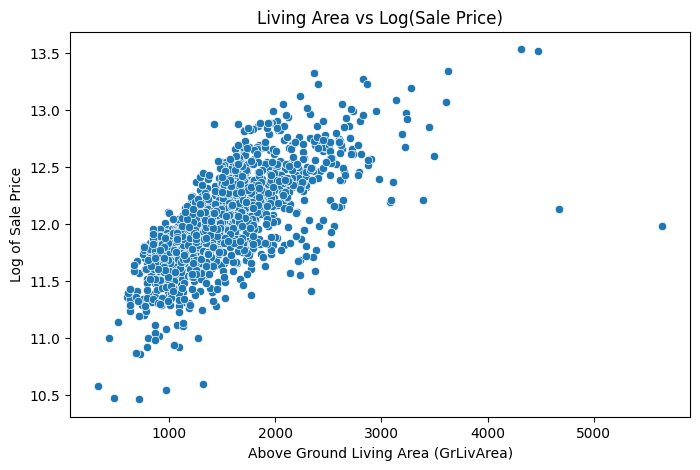

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["GrLivArea"],
    y=np.log1p(df["SalePrice"])
)
plt.title("Living Area vs Log(Sale Price)")
plt.xlabel("Above Ground Living Area (GrLivArea)")
plt.ylabel("Log of Sale Price")

plt.show()

A scatter plot was used to analyze the relationship between above-ground living area (GrLivArea) and house price.

Key Insights:
- There is a strong positive relationship between living area and house price
- Houses with larger living areas tend to have higher prices
- A few outliers are observed where very large houses are priced lower than expected

Business Insight:
Living area is one of the most important drivers of house pricing and should be a key factor in pricing and valuation models.


### 2: Feature Importance (from Random Forest)

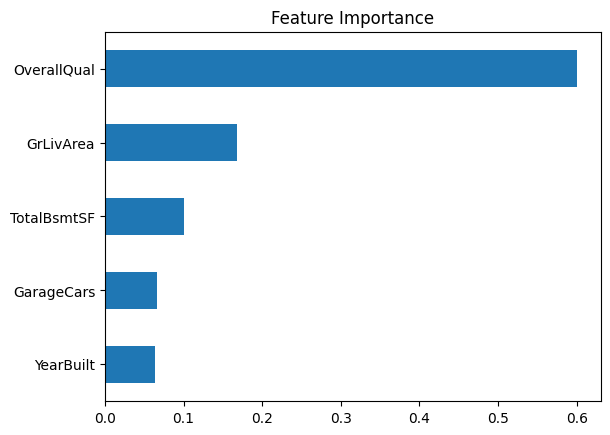

In [18]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()



A feature importance plot was generated using the Random Forest model to understand which features contribute most to predicting house prices.

Key Insights:
- OverallQual (overall quality) is the most important feature
- GrLivArea (living area) also has a significant impact
- Other features like garage capacity and basement area contribute moderately

Business Insight:
Improving the quality and usable living space of a house can significantly increase its market value. These factors should be prioritized by builders and sellers.

### 3: Actual vs Predicted Plot (Linear Regression)

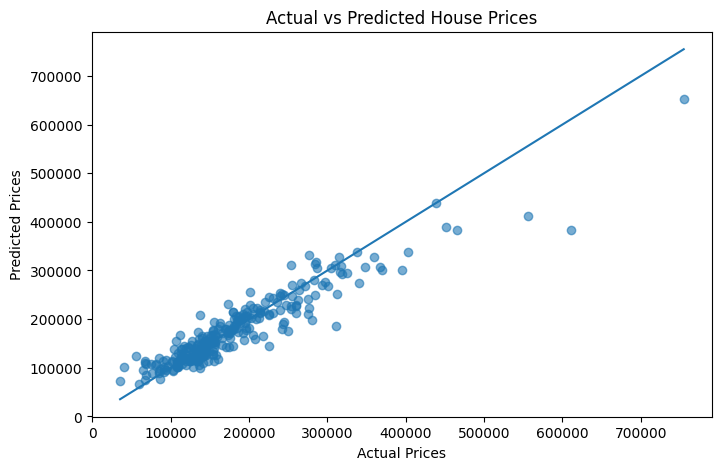

In [24]:

# Predictions from Linear Regression (already log scale)
y_pred = lr.predict(X_test_scaled)

# Convert back to actual prices
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

plt.figure(figsize=(8,5))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.6)

# perfect prediction line
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


This plot compares the actual house prices with the predicted values from the Linear Regression model.

Key Insights:
- Most points lie close to the diagonal line, indicating good prediction accuracy
- The model performs well for mid-range house prices
- Some deviations are observed for very high-priced houses

Business Insight:
The model can reliably estimate house prices for most properties but may require improvement for extreme price ranges.

## Conclusion

- Random Forest achieved the best performance with an R² score of 0.84
- Feature selection and preprocessing significantly improved model accuracy
- Key features such as overall quality and living area strongly influence house prices

This project demonstrates the importance of proper data preprocessing and feature engineering in building effective machine learning models.

### Final Insight

Overall quality and living area are the most influential factors in determining house prices.